# Diabetic Retinopathy — Part 1: Data Preprocessing (Kaggle version)

Adapted to run end-to-end on **Kaggle Notebooks** (GPU accelerator, no Google
Colab / Google Drive dependencies). Covers:

- **US1.2** — merge EyePACS/APTOS/MESSIDOR into one labelled binary (No DR vs DR)
  dataset with train/val/test manifests, split ratios and class counts logged.
- **US1.3** — reusable preprocessing/augmentation pipeline (`preprocessing_pipeline.py`).
- **US1.4** — scratch CNN baseline, trained end-to-end with logged loss/accuracy curves.
- **US1.5** — manual hyperparameter search (3 configs).
- **US1.6** — transfer-learning backbone comparison/selection note.
- Evaluation script (accuracy, sensitivity, specificity, precision, F1, AUC).

**Kaggle setup notes**
- Turn on **GPU** under *Settings → Accelerator*.
- You can either attach the dataset via **+ Add Data** → search
  `eyepacs-aptos-messidor-diabetic-retinopathy` (fastest, no download), or leave
  **Internet** on and let this notebook download it with `kagglehub`.
- Instead of physically copying/duplicating tens of thousands of images around
  disk (which is what the original Colab notebook did, and which risks
  blowing past Kaggle's `/kaggle/working` disk quota), this version builds
  lightweight CSV **manifests** (`image_path,label`) that point straight at the
  read-only source images. No image bytes are copied.


## US1.1 — Environment setup

In [1]:
# Kaggle's GPU images already ship TensorFlow, OpenCV (headless), pandas,
# scikit-learn and matplotlib. albumentations is not always preinstalled,
# so we install it quietly here.
!pip install -q albumentations kagglehub


In [2]:
import os
import random
import shutil
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
# Enable GPU memory growth up front so TensorFlow doesn't grab all VRAM at once.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"{len(gpus)} GPU(s) detected, memory growth enabled: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected -- check Settings > Accelerator on Kaggle.")


1 GPU(s) detected, memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## US1.2 (part 1) — Locate the dataset

Checks whether the dataset was attached via Kaggle's **+ Add Data** first
(instant, no download). Falls back to `kagglehub` if it wasn't attached
(requires the Internet toggle to be on).


In [4]:
DATASET_SLUG = "ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy"

kaggle_input_dir = "/kaggle/input"
attached = []
if os.path.isdir(kaggle_input_dir):
    attached = [
        os.path.join(kaggle_input_dir, d)
        for d in os.listdir(kaggle_input_dir)
        if "eyepacs" in d.lower() or "diabetic-retinopathy" in d.lower()
    ]

if attached:
    path = attached[0]
    print(f"Using dataset attached via 'Add Data': {path}")
else:
    print("Dataset not attached -- downloading via kagglehub (needs Internet ON)...")
    import kagglehub
    path = kagglehub.dataset_download(DATASET_SLUG)
    print(f"Downloaded to: {path}")


Dataset not attached -- downloading via kagglehub (needs Internet ON)...
Downloaded to: /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy


In [5]:
# Quick look at what's inside, regardless of which acquisition path was used.
for root, dirs, files in os.walk(path):
    depth = root.replace(path, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + "/")
        for f in files[:3]:
            print("  " * (depth + 1) + f)
        if len(files) > 3:
            print("  " * (depth + 1) + f"... ({len(files)} files total)")

eyepacs-aptos-messidor-diabetic-retinopathy/
  dr_unified_v2/
    dr_unified_v2/
  augmented_resized_V2/
    val/
    test/
    train/


In [6]:
def find_dir(root, target_name):
    """Locate `target_name` anywhere under `root` -- robust to whether the
    dataset came from kagglehub (versioned subfolder) or an attached Kaggle
    input (flattened)."""
    for dirpath, dirnames, _ in os.walk(root):
        if target_name in dirnames:
            return os.path.join(dirpath, target_name)
    raise FileNotFoundError(f"Could not locate '{target_name}' under {root}")

base_path = find_dir(path, "augmented_resized_V2")
print("base_path:", base_path)


base_path: /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/augmented_resized_V2


In [7]:
# Per-split, per-class image counts straight from the source folders.
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    split_path = os.path.join(base_path, split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            print(f"Class {cls}: {len(os.listdir(cls_path))} images")



TRAIN
Class 0: 55162 images
Class 1: 18470 images
Class 2: 24198 images
Class 3: 7936 images
Class 4: 9475 images

VAL
Class 0: 6895 images
Class 1: 1840 images
Class 2: 3024 images
Class 3: 1000 images
Class 4: 1468 images

TEST
Class 0: 6896 images
Class 1: 1862 images
Class 2: 2999 images
Class 3: 978 images
Class 4: 1466 images


## US1.2 (part 2) — Merge into a single binary-labelled manifest

Class `0` (No DR) stays label `0`; classes `1`-`4` (all DR severities) collapse
to label `1` (DR). This builds an `(image_path, label)` manifest per split
**without copying any image bytes** -- `image_path` still points at the
original file on the read-only dataset mount.


In [8]:
def build_binary_manifest(base_path, split):
    rows = []
    split_path = os.path.join(base_path, split)
    for cls in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, cls)
        if not os.path.isdir(class_path):
            continue
        binary_label = 0 if cls == "0" else 1
        for img in os.listdir(class_path):
            if img.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append({
                    "image_path": os.path.join(class_path, img),
                    "label": binary_label,
                })
    return pd.DataFrame(rows)

full_manifests = {
    split: build_binary_manifest(base_path, split)
    for split in ["train", "val", "test"]
}

for split, df in full_manifests.items():
    print(f"\n{split.upper()} (merged binary labels)")
    print(df["label"].value_counts().sort_index().rename({0: "No DR", 1: "DR"}))



TRAIN (merged binary labels)
label
No DR    55162
DR       60079
Name: count, dtype: int64

VAL (merged binary labels)
label
No DR    6895
DR       7332
Name: count, dtype: int64

TEST (merged binary labels)
label
No DR    6896
DR       7305
Name: count, dtype: int64


In [9]:
# Log the full (pre-balancing) class counts -- US1.2 AC: "class counts logged".
full_counts = pd.DataFrame({
    split: df["label"].value_counts().sort_index()
    for split, df in full_manifests.items()
})
full_counts.index = ["No DR", "DR"]
full_counts.to_csv("binary_class_counts_full.csv")
full_counts


,train,val,test
No DR,55162,6895,6896
DR,60079,7332,7305


## Balance the training split

Only the **training** split is rebalanced (undersampling the majority class
so the CNN doesn't just learn to predict "No DR"). Validation and test stay
at their natural class distribution so reported metrics reflect real-world
performance.


In [10]:
def undersample_binary(df, seed=SEED):
    class0 = df[df["label"] == 0]
    class1 = df[df["label"] == 1]
    n = min(len(class0), len(class1))
    class0 = class0.sample(n=n, random_state=seed)
    class1 = class1.sample(n=n, random_state=seed)
    return (
        pd.concat([class0, class1])
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

balanced_manifests = dict(full_manifests)
balanced_manifests["train"] = undersample_binary(full_manifests["train"])

for split, df in balanced_manifests.items():
    print(f"\n{split.upper()} (train balanced, val/test untouched)")
    print(df["label"].value_counts().sort_index().rename({0: "No DR", 1: "DR"}))



TRAIN (train balanced, val/test untouched)
label
No DR    55162
DR       55162
Name: count, dtype: int64

VAL (train balanced, val/test untouched)
label
No DR    6895
DR       7332
Name: count, dtype: int64

TEST (train balanced, val/test untouched)
label
No DR    6896
DR       7305
Name: count, dtype: int64


## Working subset for this Kaggle session

A single free Kaggle GPU session has a limited weekly quota, so -- exactly
like the earlier local run -- we sample a small, fixed fraction of each
class/split to keep training time reasonable. This is purely a row-sample of
the manifest (no copying), so it's cheap and instant to change: bump
`FRACTION` up if you have more GPU budget to spend.


In [11]:
FRACTION = 0.05  # 5% subset, matches the earlier local run's "data_5"

def sample_fraction(df, fraction=FRACTION, seed=SEED):
    return (
        df.groupby("label", group_keys=False)
          .apply(lambda g: g.sample(frac=fraction, random_state=seed))
          .reset_index(drop=True)
    )

data_manifests = {
    split: sample_fraction(df) for split, df in balanced_manifests.items()
}

for split, df in data_manifests.items():
    print(f"\n{split.upper()} (working subset, {FRACTION:.0%})")
    print(df["label"].value_counts().sort_index().rename({0: "No DR", 1: "DR"}))



TRAIN (working subset, 5%)
label
No DR    2758
DR       2758
Name: count, dtype: int64

VAL (working subset, 5%)
label
No DR    345
DR       367
Name: count, dtype: int64

TEST (working subset, 5%)
label
No DR    345
DR       365
Name: count, dtype: int64


/tmp/ipykernel_22/4208868429.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=fraction, random_state=seed))
/tmp/ipykernel_22/4208868429.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=fraction, random_state=seed))
/tmp/ipykernel_22/4208868429.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, 

In [12]:
train_df = data_manifests["train"]
val_df = data_manifests["val"]
test_df = data_manifests["test"]

train_df.to_csv("train_binary.csv", index=False)
val_df.to_csv("val_binary.csv", index=False)
test_df.to_csv("test_binary.csv", index=False)

print(f"train_binary.csv created with {len(train_df)} images")
print(f"val_binary.csv created with {len(val_df)} images")
print(f"test_binary.csv created with {len(test_df)} images")


train_binary.csv created with 5516 images
val_binary.csv created with 712 images
test_binary.csv created with 710 images


In [13]:
train_total = len(train_df)
val_total = len(val_df)
test_total = len(test_df)
total = train_total + val_total + test_total

print(f"Training   : {train_total} ({train_total/total:.2%})")
print(f"Validation : {val_total} ({val_total/total:.2%})")
print(f"Testing    : {test_total} ({test_total/total:.2%})")


Training   : 5516 (79.50%)
Validation : 712 (10.26%)
Testing    : 710 (10.23%)


In [14]:
summary = pd.DataFrame({
    "Training": train_df["label"].value_counts().sort_index(),
    "Validation": val_df["label"].value_counts().sort_index(),
    "Testing": test_df["label"].value_counts().sort_index(),
})
summary.index = ["No DR", "DR"]
summary.to_csv("binary_class_counts.csv", index=True)
print("binary_class_counts.csv saved")
summary


binary_class_counts.csv saved


,Training,Validation,Testing
No DR,2758,345,345
DR,2758,367,365


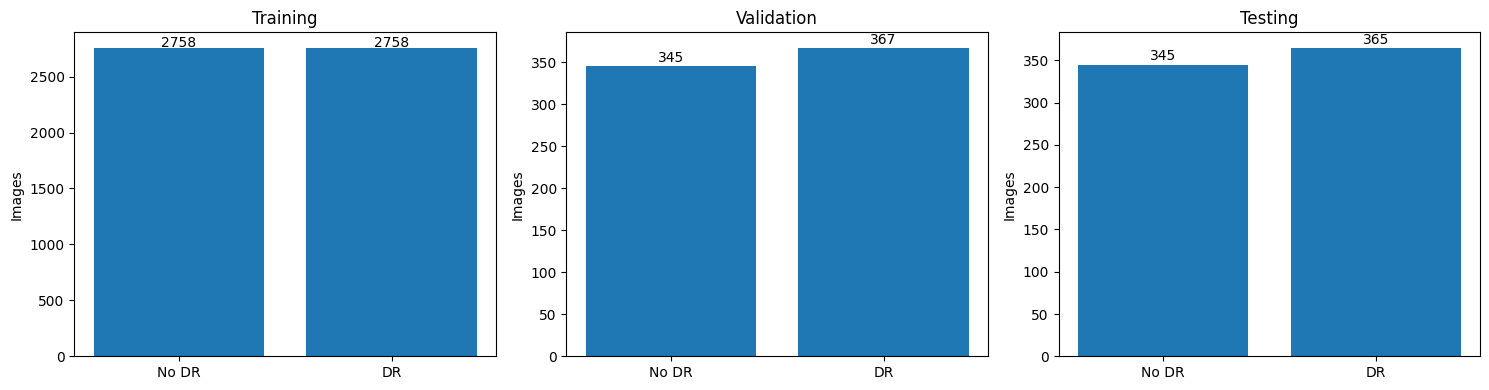

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [("Training", train_df), ("Validation", val_df), ("Testing", test_df)]

for ax, (title, df) in zip(axes, datasets):
    counts = df["label"].value_counts().sort_index()
    bars = ax.bar(["No DR", "DR"], counts)
    ax.set_title(title)
    ax.set_ylabel("Images")
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            int(bar.get_height()),
            ha="center",
        )

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


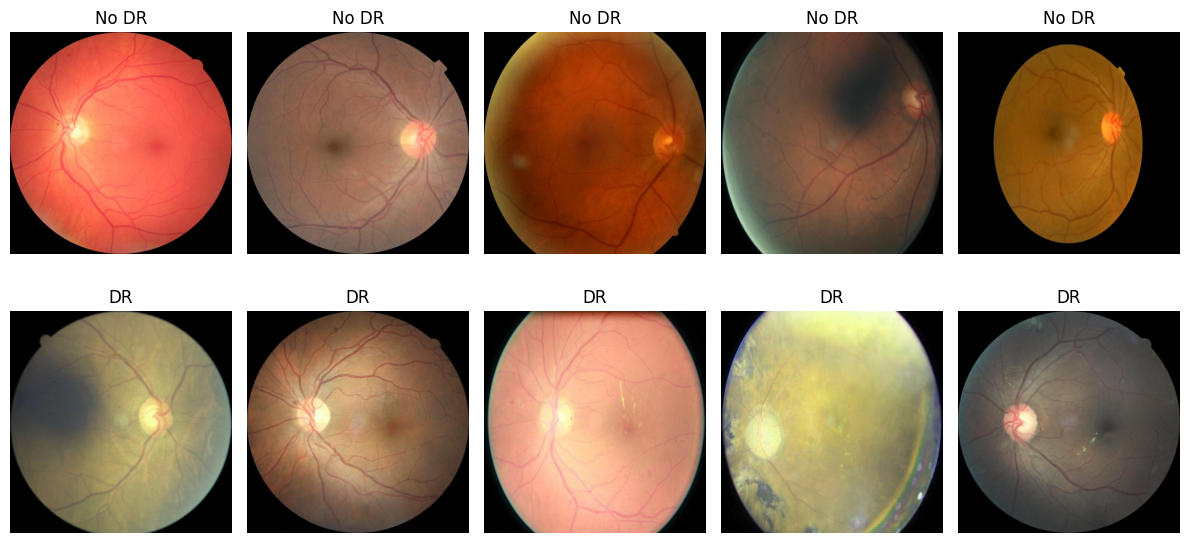

In [16]:
fig, ax = plt.subplots(2, 5, figsize=(12, 6))

for label in [0, 1]:
    paths = train_df[train_df["label"] == label]["image_path"].tolist()
    samples = random.sample(paths, min(5, len(paths)))
    for i, p in enumerate(samples):
        img = Image.open(p)
        ax[label, i].imshow(img)
        ax[label, i].axis("off")
        ax[label, i].set_title("No DR" if label == 0 else "DR")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()


## US1.3 — Reusable preprocessing/augmentation pipeline

Standalone module (`preprocessing_pipeline.py`) so the scratch CNN and the
transfer-learning model consume identical preprocessing: black-border crop,
resize, Ben Graham contrast enhancement, normalization, and (train-only)
albumentations augmentation, wired into a `tf.data` pipeline.


In [17]:
%%writefile preprocessing_pipeline.py
from dataclasses import dataclass
import albumentations as A
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf


# ---------------------------------------------------------
# Deterministic preprocessing
# ---------------------------------------------------------
def crop_black_borders(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]


def ben_graham_preprocess(img, sigma_frac=10):
    sigma = img.shape[1] / sigma_frac
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    img = cv2.addWeighted(img, 4, blurred, -4, 128)
    return img


def preprocess(image, image_size=224):
    image = crop_black_borders(image)
    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
    image = ben_graham_preprocess(image)
    image = image.astype(np.float32) / 255.0
    return image


# ---------------------------------------------------------
# Training augmentations
# ---------------------------------------------------------
train_augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, border_mode=cv2.BORDER_CONSTANT, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.2),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(10, 20),
        hole_width_range=(10, 20),
        p=0.2,
    ),
])


def augment(image):
    img = (image * 255).astype(np.uint8)
    img = train_augmenter(image=img)["image"]
    img = img.astype(np.float32) / 255.0
    return img


# ---------------------------------------------------------
# tf.data Pipeline
# ---------------------------------------------------------
@dataclass
class DRDataPipeline:
    image_size: int = 224
    batch_size: int = 32
    num_classes: int = 2

    def _load_image(self, path, augment_flag):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess(img, self.image_size)
        if augment_flag:
            img = augment(img)
        return img

    def _tf_wrapper(self, path, label, augment_flag):
        def _py_function(path, label):
            path = path.numpy().decode("utf-8")
            image = self._load_image(path, augment_flag)
            return image.astype(np.float32), label

        image, label = tf.py_function(_py_function, [path, label], [tf.float32, tf.int32])
        image.set_shape((self.image_size, self.image_size, 3))
        label.set_shape(())
        label = tf.one_hot(label, depth=self.num_classes)
        return image, label

    def build_dataset(self, csv_file, augment=False, shuffle=False):
        df = pd.read_csv(csv_file)
        paths = df["image_path"].values
        labels = df["label"].values.astype(np.int32)
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        if shuffle:
            dataset = dataset.shuffle(len(df), reshuffle_each_iteration=True)
        dataset = dataset.map(
            lambda x, y: self._tf_wrapper(x, y, augment),
            num_parallel_calls=4,  # cap workers to Kaggle's typical 4 vCPUs
        )
        dataset = dataset.batch(self.batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset


Writing preprocessing_pipeline.py


In [18]:
from preprocessing_pipeline import DRDataPipeline

IMAGE_SIZE = 224
NUM_CLASSES = 2

pipeline = DRDataPipeline(image_size=IMAGE_SIZE, batch_size=16, num_classes=NUM_CLASSES)

train_ds = pipeline.build_dataset("train_binary.csv", augment=True, shuffle=True)
val_ds = pipeline.build_dataset("val_binary.csv", augment=False, shuffle=False)
test_ds = pipeline.build_dataset("test_binary.csv", augment=False, shuffle=False)


I0000 00:00:1784793601.563771      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [19]:
images, labels = next(iter(train_ds))
print("batch image shape:", images.shape)
print("batch label shape:", labels.shape)
print("label sample:", labels[0].numpy())


batch image shape: (16, 224, 224, 3)
batch label shape: (16, 2)
label sample: [0. 1.]


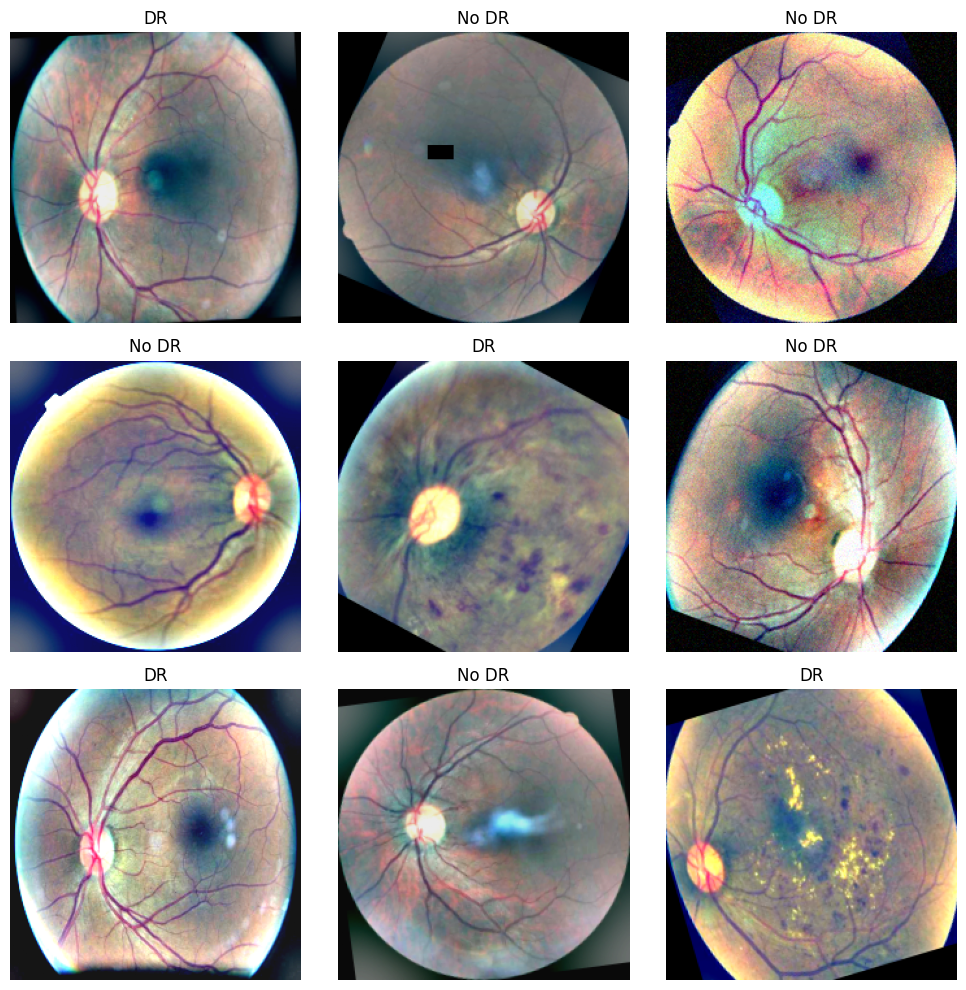

In [20]:
plt.figure(figsize=(10, 10))
for i in range(min(9, images.shape[0])):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("No DR" if np.argmax(labels[i]) == 0 else "DR")
    plt.axis("off")
plt.tight_layout()
plt.savefig("pipeline_batch_sample.png", dpi=150)
plt.show()


## US1.4 — Scratch CNN baseline

A CNN trained from scratch (no pretrained weights) as the baseline model.


In [21]:
def build_scratch_cnn(image_size=224, num_classes=2):
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)
        return x

    inputs = layers.Input(shape=(image_size, image_size, 3))
    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="scratch_cnn")


model = build_scratch_cnn(IMAGE_SIZE, NUM_CLASSES)
model.summary()


Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             

 Total params: 2,391,458 (9.12 MB)

 Trainable params: 2,388,514 (9.11 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [22]:
# Class weights from the working-subset counts, to feed model.fit.
counts_df = pd.read_csv("binary_class_counts.csv")
counts_df = counts_df.rename(columns={"Unnamed: 0": "class_name"})

count_no_dr = counts_df.loc[counts_df["class_name"] == "No DR", "Training"].values[0]
count_dr = counts_df.loc[counts_df["class_name"] == "DR", "Training"].values[0]
total = count_no_dr + count_dr

class_weight = {
    0: total / (2 * count_no_dr),
    1: total / (2 * count_dr),
}
print("class_weight:", class_weight)


class_weight: {0: np.float64(1.0), 1: np.float64(1.0)}


Epoch 1/30
  3/345 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.4896 - loss: 1.0598   

I0000 00:00:1784793627.095971      73 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


345/345 ━━━━━━━━━━━━━━━━━━━━ 182s 473ms/step - accuracy: 0.5916 - loss: 0.6836 - val_accuracy: 0.5281 - val_loss: 0.8481 - learning_rate: 0.0010
Epoch 2/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 152s 440ms/step - accuracy: 0.6887 - loss: 0.5897 - val_accuracy: 0.5435 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 3/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 149s 432ms/step - accuracy: 0.7362 - loss: 0.5357 - val_accuracy: 0.5379 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 4/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 149s 432ms/step - accuracy: 0.7534 - loss: 0.5122 - val_accuracy: 0.7219 - val_loss: 0.5405 - learning_rate: 0.0010
Epoch 5/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 158s 456ms/step - accuracy: 0.7712 - loss: 0.4860 - val_accuracy: 0.5674 - val_loss: 0.7964 - learning_rate: 0.0010
Epoch 6/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 152s 441ms/step - accuracy: 0.7689 - loss: 0.4822 - val_accuracy: 0.6938 - val_loss: 0.7151 - learning_rate: 0.0010
Epoch 7/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 152s 440ms/step - accuracy: 0.7796 

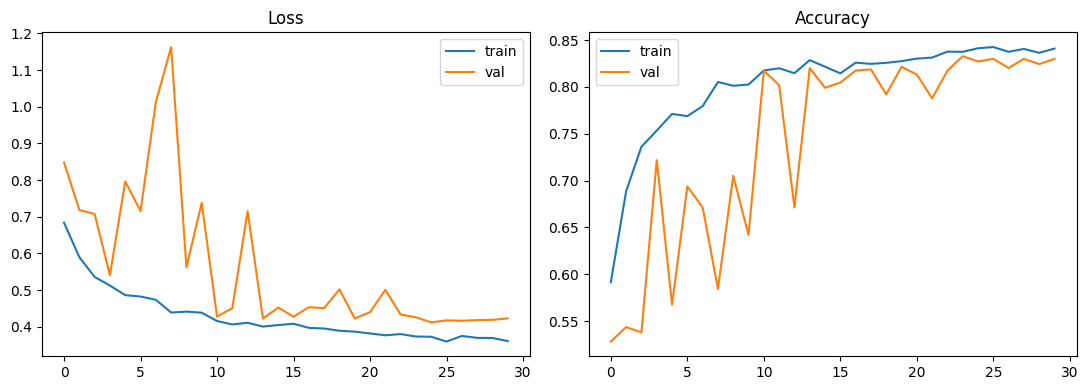

In [23]:
EPOCHS = 30

model = build_scratch_cnn(IMAGE_SIZE, NUM_CLASSES)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint("best_scratch_cnn.keras", monitor="val_accuracy", save_best_only=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[early_stop, checkpoint, reduce_lr],
)

# US1.4 AC deliverable: loss/accuracy curves logged.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig("curves_baseline.png", dpi=150)
plt.show()


## US1.5 — Manual hyperparameter search (≥3 configs)

Three configurations varying learning rate and dropout; best config picked
by validation accuracy.


In [24]:
BATCH_SIZE = 16

configs = [
    {"name": "config_A_baseline", "learning_rate": 1e-3, "dropout": (0.4, 0.3)},
    {"name": "config_B_lower_lr", "learning_rate": 3e-4, "dropout": (0.4, 0.3)},
    {"name": "config_C_more_dropout", "learning_rate": 1e-4, "dropout": (0.5, 0.4)},
]

SEARCH_EPOCHS = 10
results = []


def build_scratch_cnn_configurable(image_size, num_classes, dropout1, dropout2):
    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)
        return x

    inputs = layers.Input(shape=(image_size, image_size, 3))
    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout1)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout2)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs)


for cfg in configs:
    print(f"\n=== Running {cfg['name']} ===")

    pipeline_cfg = DRDataPipeline(image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, num_classes=NUM_CLASSES)
    train_ds_cfg = pipeline_cfg.build_dataset("train_binary.csv", augment=True, shuffle=True)
    val_ds_cfg = pipeline_cfg.build_dataset("val_binary.csv", augment=False, shuffle=False)

    model_cfg = build_scratch_cnn_configurable(IMAGE_SIZE, NUM_CLASSES, *cfg["dropout"])
    model_cfg.compile(
        optimizer=optimizers.Adam(learning_rate=cfg["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop_cfg = callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)

    hist = model_cfg.fit(
        train_ds_cfg,
        validation_data=val_ds_cfg,
        epochs=SEARCH_EPOCHS,
        class_weight=class_weight,
        callbacks=[early_stop_cfg],
        verbose=1,
    )

    results.append({
        "name": cfg["name"],
        "learning_rate": cfg["learning_rate"],
        "dropout": cfg["dropout"],
        "best_val_accuracy": max(hist.history["val_accuracy"]),
        "best_val_loss": min(hist.history["val_loss"]),
    })

    print(
        f"{cfg['name']} -> best_val_acc={max(hist.history['val_accuracy']):.4f}, "
        f"best_val_loss={min(hist.history['val_loss']):.4f}"
    )

results_df = pd.DataFrame(results).sort_values(by="best_val_accuracy", ascending=False)
print("\n=== Hyperparameter Search Results ===")
print(results_df)

with open("hyperparam_search_results.json", "w") as f:
    json.dump(results, f, indent=4)

best_config = results_df.iloc[0]
print(
    f"\nBest Configuration: {best_config['name']}"
    f"\nLearning Rate: {best_config['learning_rate']}"
    f"\nDropout: {best_config['dropout']}"
    f"\nValidation Accuracy: {best_config['best_val_accuracy']:.4f}"
)



=== Running config_A_baseline ===
Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 169s 448ms/step - accuracy: 0.6128 - loss: 0.6747 - val_accuracy: 0.5407 - val_loss: 0.9580
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 151s 437ms/step - accuracy: 0.6746 - loss: 0.6070 - val_accuracy: 0.5267 - val_loss: 0.7193
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 151s 436ms/step - accuracy: 0.7224 - loss: 0.5502 - val_accuracy: 0.6053 - val_loss: 0.6817
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 151s 437ms/step - accuracy: 0.7493 - loss: 0.5085 - val_accuracy: 0.7570 - val_loss: 0.5108
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 200s 433ms/step - accuracy: 0.7728 - loss: 0.4873 - val_accuracy: 0.6840 - val_loss: 0.8172
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 151s 436ms/step - accuracy: 0.7710 - loss: 0.4886 - val_accuracy: 0.7851 - val_loss: 0.4959
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 151s 436ms/step - accuracy: 0.7877 - loss: 0.4658 - val_accuracy: 0.7051 - val_loss: 0.6193
Epoch 8/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 1

## US1.6 — Transfer learning backbone comparison

Short comparison of candidate ImageNet backbones (parameter count / depth)
to justify the backbone chosen for the transfer-learning model in the next
notebook.


In [25]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2

candidates = {
    "EfficientNetB0": EfficientNetB0,
    "ResNet50": ResNet50,
    "MobileNetV2": MobileNetV2,
}

backbone_comparison = []
for name, model_fn in candidates.items():
    backbone = model_fn(include_top=False, weights="imagenet", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    total_params = backbone.count_params()
    backbone_comparison.append({
        "name": name,
        "total_params_millions": round(total_params / 1e6, 2),
        "num_layers": len(backbone.layers),
    })
    del backbone  # free memory before loading the next one

comparison_df = pd.DataFrame(backbone_comparison)
comparison_df.to_csv("backbone_comparison.csv", index=False)
print(comparison_df)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
             name  total_params_millions  num_layers
0  EfficientNetB0                   4.05         238
1        ResNet50                  23.59         175
2     MobileNetV2                   2.26         154


## Evaluation metrics for the scratch CNN

Single evaluation function (accuracy, sensitivity, specificity, precision,
F1, AUC) so all models can be scored consistently — feeds US2.3's shared
evaluation script.


In [26]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
)


def evaluate_model(model, dataset, dataset_name="Test"):
    y_true, y_pred, y_prob = [], [], []

    for imgs, lbls in dataset:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(lbls.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        y_prob.extend(preds[:, 1])  # probability of class 1 = "DR"

    y_true, y_pred, y_prob = np.array(y_true), np.array(y_pred), np.array(y_prob)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1,
        "auc": auc,
        "confusion_matrix": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
    }

    print(f"=== {dataset_name} Set Metrics ===")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}  (aka Recall -- TP / (TP+FN))")
    print(f"Specificity: {specificity:.4f}  (TN / (TN+FP))")
    print(f"Precision:   {precision:.4f}")
    print(f"F1 Score:    {f1:.4f}")
    print(f"AUC:         {auc:.4f}")
    print(f"Confusion Matrix -- TN:{tn} FP:{fp} FN:{fn} TP:{tp}")

    return metrics, y_true, y_pred, y_prob


val_metrics, _, _, _ = evaluate_model(model, val_ds, "Validation")
test_metrics, y_true_test, y_pred_test, y_prob_test = evaluate_model(model, test_ds, "Test")

with open("scratch_cnn_metrics.json", "w") as f:
    json.dump({"validation": val_metrics, "test": test_metrics}, f, indent=2)


=== Validation Set Metrics ===
Accuracy:    0.8329
Sensitivity: 0.7357  (aka Recall -- TP / (TP+FN))
Specificity: 0.9362  (TN / (TN+FP))
Precision:   0.9247
F1 Score:    0.8194
AUC:         0.8813
Confusion Matrix -- TN:323 FP:22 FN:97 TP:270
=== Test Set Metrics ===
Accuracy:    0.8282
Sensitivity: 0.7233  (aka Recall -- TP / (TP+FN))
Specificity: 0.9391  (TN / (TN+FP))
Precision:   0.9263
F1 Score:    0.8123
AUC:         0.9025
Confusion Matrix -- TN:324 FP:21 FN:101 TP:264


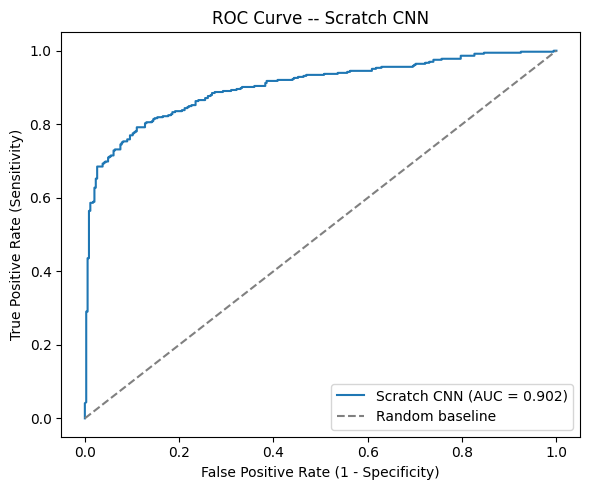

In [27]:
fpr, tpr, thresholds = roc_curve(y_true_test, y_prob_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Scratch CNN (AUC = {test_metrics['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve -- Scratch CNN")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_scratch_cnn.png", dpi=150)
plt.show()
